# Credit default swaps

Relate survival, recovery and protection payments to the premium leg.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

A CDS protection buyer pays premiums while a reference entity survives and receives compensation after a covered default. Pricing requires both the survival distribution and the loss given default; a credit spread alone does not uniquely identify default probability without further assumptions.

This chapter uses a continuous-premium approximation with constant risk-neutral hazard $\lambda$, recovery $R$ and discount rate $r$. Survival is $Q(t)=e^{-\lambda t}$. The risky premium annuity is $A=\int_0^T e^{-(r+\lambda)t}dt$ and the protection value per unit notional is $(1-R)\lambda A$. The fair continuous spread is therefore $s^*=(1-R)\lambda$.

At $T=5$, $r=3.5\%$, $\lambda=2\%$ and $R=40\%$, numerical quadrature independently checks the analytical annuity. The notebook compares premium and protection values, plots fair spreads across hazard/recovery assumptions, and verifies that the fair contract has zero PV. The probabilities are model assumptions under a pricing measure, not estimated frequencies or default forecasts.

Continuous premiums avoid the quarterly coupon schedule and accrued premium at default that a standard contract needs. The example omits upfront payments, settlement delays, restructuring/documentation terms and calibration to a spread term structure. It is an analytical teaching case, not an implementation or validation of the ISDA Standard Model.

For standard contract pricing and consistent conversion between upfront amounts and quoted spreads, the primary reference is the [ISDA CDS Standard Model](https://www.cdsmodel.com/). A credible market extension would compare an implementation against its test grids using fully specified dates, recovery and input curves.

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
from scipy.integrate import quad
T,r,hazard,recovery,notional=5.0,.035,.02,.40,100.0
annuity=-np.expm1(-(r+hazard)*T)/(r+hazard)
quadrature=quad(lambda t:np.exp(-(r+hazard)*t),0,T)[0]
fair_spread=(1-recovery)*hazard
premium=notional*fair_spread*annuity
protection=notional*(1-recovery)*hazard*annuity
assert abs(annuity-quadrature)<1e-12
assert abs(protection-premium)<1e-12
assert 0<np.exp(-hazard*T)<1
summary=pd.DataFrame([{'hazard_pct':100*hazard,'recovery_pct':100*recovery,'five_year_survival':np.exp(-hazard*T),'fair_continuous_spread_bp':1e4*fair_spread,'premium_PV':premium,'protection_PV':protection}])
display(summary.round(6))

,hazard_pct,recovery_pct,five_year_survival,fair_continuous_spread_bp,premium_PV,protection_PV
0,2.0,40.0,0.904837,120.0,5.245699,5.245699


## Economic relationship

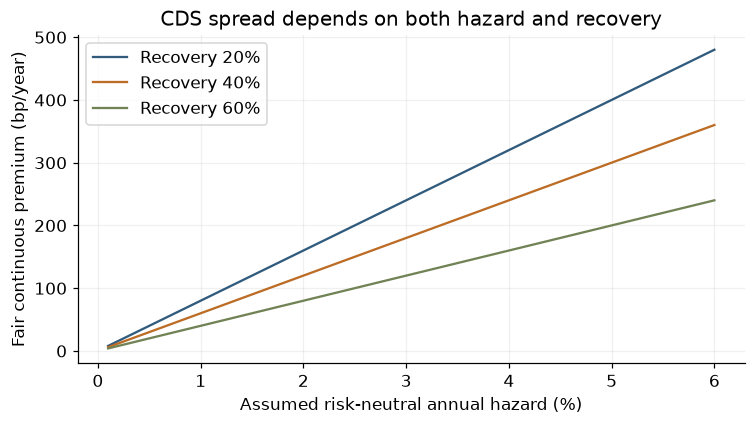

In [3]:
hazards=np.linspace(.001,.06,60)
fig,ax=plt.subplots(figsize=(7,4))
for rec,color in [(0.2,'#315b7d'),(0.4,'#bc6c25'),(0.6,'#718355')]:
    ax.plot(100*hazards,1e4*(1-rec)*hazards,label=f'Recovery {rec:.0%}',color=color)
ax.set(xlabel='Assumed risk-neutral annual hazard (%)',ylabel='Fair continuous premium (bp/year)',title='CDS spread depends on both hazard and recovery')
ax.legend();fig.tight_layout();plt.show()

## Interpretation

The fair continuous premium is 120 bp/year for the declared 2% hazard and 40% recovery. Different recovery assumptions map the same hazard to different spreads; this does not calibrate a standard quarterly CDS.